In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

matplotlib_font_size = 7
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = matplotlib_font_size

repo_root = Path.cwd().parent.parent
path_figures = repo_root / 'figures'
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data = repo_root / 'benchmark_search_global_repository'

In [37]:
steps = ['open_search', 'neutral_loss_search', 'hybrid_search']
query_sizes = [1, 10, 100, 1000]
ion_modes = [-1, 1]

In [38]:
records = []
for query_size in query_sizes:
    for charge in ion_modes:
        data_dir = path_benchmark_data / f'query_num_{query_size}_charge_{charge}'
        for step in steps:
            total_time = 0.0
            for query_idx in range(query_size):
                data_file = data_dir / (
                    f'repository_{charge}_repository_compare_time_{step}_step_query_{query_idx}.txt'
                )
                with data_file.open() as handle:
                    total_time += float(handle.readline().strip())
            records.append({
                'query_size': query_size,
                'charge': charge,
                'search_type': step,
                'total_time': total_time,
            })

df = pd.DataFrame.from_records(records)
df

,query_size,charge,search_type,total_time
0,1,-1,open_search,13.413600
1,1,-1,neutral_loss_search,12.952299
2,1,-1,hybrid_search,18.166414
3,1,1,open_search,51.622682
4,1,1,neutral_loss_search,56.325061
5,1,1,hybrid_search,69.061903
6,10,-1,open_search,135.736750
7,10,-1,neutral_loss_search,123.319597
8,10,-1,hybrid_search,162.087950
9,10,1,open_search,550.047377


In [39]:
df_data = df[['query_size', 'charge', 'search_type', 'total_time']]
df_data

,query_size,charge,search_type,total_time
0,1,-1,open_search,13.413600
1,1,-1,neutral_loss_search,12.952299
2,1,-1,hybrid_search,18.166414
3,1,1,open_search,51.622682
4,1,1,neutral_loss_search,56.325061
5,1,1,hybrid_search,69.061903
6,10,-1,open_search,135.736750
7,10,-1,neutral_loss_search,123.319597
8,10,-1,hybrid_search,162.087950
9,10,1,open_search,550.047377


In [40]:
def plot_total_time_different_query_num_repository(
    df, search_type, color_palette, ylim, save_path
):
    fig, axes = plt.subplots(1, 2, figsize=(6, 2.8), sharex=True, sharey=True)
    search_data = df[df['search_type'] == search_type]

    for idx, charge in enumerate(ion_modes):
        ax = axes[idx]
        subset = (search_data[search_data['charge'] == charge]
                  .set_index('query_size').reindex(query_sizes).reset_index())
        sns.lineplot(x=range(len(query_sizes)), y=subset['total_time'],
                     color=color_palette[charge], marker='o', markersize=5,
                     linewidth=0.8, ax=ax)
        ax.set_xticks(range(len(query_sizes)),
                      labels=[str(query_size) for query_size in query_sizes])
        ax.set_yscale('log')
        ax.set_ylim(ylim)
        ax.set_title(charge_labels[charge])
        ax.set_xlabel('Number of query spectra')
        ax.set_ylabel('Total Library Search Time (s)' if idx == 0 else '')
        ax.grid(True, which='both', axis='y', alpha=0.5, linewidth=0.3)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
        ax.tick_params(axis='both', which='both', width=0.5)

    fig.suptitle(search_type.replace('_', ' ').title())
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches='tight', dpi=1200)
    return fig, axes

In [41]:
color_palette = {
    1: '#FCD470',
    -1: '#66BC98'
}
charge_labels = {-1: '(-) ESI', 1: '(+) ESI'}

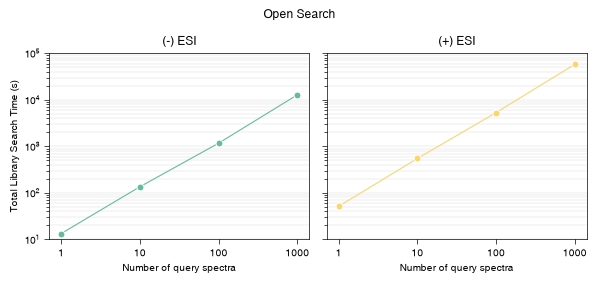

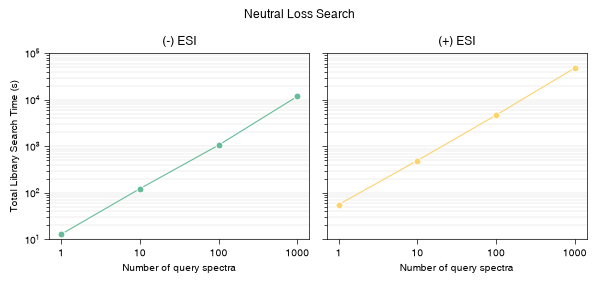

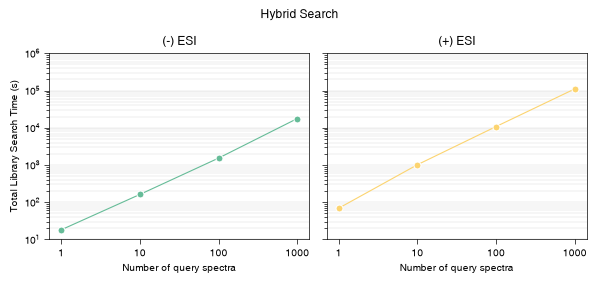

In [42]:
every_ylim = {
    'open_search': (1e1, 1e5),
    'neutral_loss_search': (1e1, 1e5),
    'hybrid_search': (1e1, 1e6),
}
figures = {}
for search_type in steps:
    save_path = path_figures / f'compare_total_time_different_query_num_repository_{search_type}.svg'
    figures[search_type] = plot_total_time_different_query_num_repository(
        df=df_data, search_type=search_type, color_palette=color_palette,
        ylim=every_ylim[search_type], save_path=save_path
    )[0]